# Exploratory Data Analysis (EDA) for the `flight_data_2024` dataset

## Engine Setup and Initialization

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Basic imports completed!")

import pyspark.sql.functions as F
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan, countDistinct
print("PySpark import completed!")

Basic imports completed!
PySpark import completed!


In [2]:
# aesthetic configuration of the graphs
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
print("Spark Session initialization...")

# uses "local[*]" to tell Spark to use all cores on my Mac
spark = SparkSession.builder \
    .appName("FlightData_Full_EDA") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("\nSpark ready!")

Spark Session initialization...


26/05/06 10:00:18 WARN Utils: Your hostname, MacBook-Air-di-Irene.local resolves to a loopback address: 127.0.0.1; using 192.168.1.202 instead (on interface en0)
26/05/06 10:00:18 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/06 10:00:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/06 10:00:21 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.



Spark ready!


## Dataset Loading and Inspection

### Dimensional Analysis

In [4]:
# Calculation of the absolute path
# disables Hadoop/HDFS search and forces local reading
absolute_path = os.path.abspath("dataset/raw/flight_data_2024.csv")
file_path = f"file://{absolute_path}"

print(f"Attempt to read from the guaranteed local path:\n{file_path}\n")

print("Reading file in progress...")
# inferSchema=False avoids scanning data types line by line, speeding up loading
df_full = spark.read.csv(file_path, header=True, inferSchema=False)

print("\nCalculating total number of rows...")
total_rows = df_full.count()
total_cols = len(df_full.columns)
print(f"Dataset Dimensions: {total_rows:,} rows x {total_cols} columns.")

Attempt to read from the guaranteed local path:
file:///Users/fnene/Desktop/mybd/Flight-Delay_Project/dataset/raw/flight_data_2024.csv

Reading file in progress...



Calculating total number of rows...


Dataset Dimensions: 7,079,081 rows x 35 columns.


*Observation*: **7,079,081 rows and 35 columns** were **loaded and counted in 17.3 seconds**, this can be possible because Spark divided the work into 10 parallel "tasks" using all processor cores.

### Structural Analysis

In [5]:
print("Dataset Schema:")
# returns a list of tuples
schema_grezzo = df_full.dtypes
# convert to DataFrame for better visualization
df_schema = pd.DataFrame(schema_grezzo, columns=["Column Name", "Spark Data Type"])
# numeric index for the columns
df_schema.index = df_schema.index + 1

display(df_schema)

Dataset Schema:


,Column Name,Spark Data Type
1,year,string
2,month,string
3,day_of_month,string
4,day_of_week,string
5,fl_date,string
6,op_unique_carrier,string
7,op_carrier_fl_num,string
8,origin,string
9,origin_city_name,string
10,origin_state_nm,string


In [6]:
print("Data preview (first 5 rows):")
preview_data = df_full.limit(5).collect()
df_preview = pd.DataFrame([row.asDict() for row in preview_data])

display(df_preview)

Data preview (first 5 rows):


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


## Data Quality & Feature Selection

### Zero-Variance Analysis
To determine which attributes have zero variance, we opted for a **comparison between the min and max values**, rather than other solutions that would have required a (very heavy) shuffle operation.

All **columns with zero variance can be removed** from the dataset during the *Feature Selection* phase.

In [7]:
# list to store columns with zero variance
zero_variance_cols = []

# create a list of instructions to calculate min and max for each column
exprs = [F.min(F.col(c)).alias(f"min_{c}") for c in df_full.columns] + [F.max(F.col(c)).alias(f"max_{c}") for c in df_full.columns]
# aggregation to get min and max values for all columns
min_max_row = df_full.select(*exprs).collect()[0].asDict()

print("Checking for min and max values for each column...")
# check if min and max are the same for each column
for c in df_full.columns:
    if min_max_row[f"min_{c}"] == min_max_row[f"max_{c}"]:
        zero_variance_cols.append(c)

print(f"\nZero-variance Columns: {zero_variance_cols}")

Checking for min and max values for each column...

Zero-variance Columns: ['year']


*Observation*: the only column with zero variance is the `year` attribute, which is expected since the dataset contains flight data for 2024.

### Redundancy Analysis
Analysis over a **5% sample to speed up** operations.

In [8]:
# create a smaller sample for quick EDA (5% of the data)
df_sample_quick = df_full.sample(fraction=0.05, seed=42)

# automatically identify columns that likely represent IDs (contain "_id" in their name)
id_cols = [c for c in df_full.columns if "_id" in c.lower()]
redundant_cols = []

print("Cardinality check in progress...")
for c in id_cols:
    base_col = c.lower().replace("_airport_id", "").replace("_id", "")
    if base_col in df_full.columns:
        count_id = df_sample_quick.select(c).distinct().count()
        count_base = df_sample_quick.select(base_col).distinct().count()

        if count_id == count_base:
            redundant_cols.append(c)

print(f"\nRedundant columns: {redundant_cols}")

Cardinality check in progress...

Redundant columns: []


### Sparsity Analysis
The sample is used again: if a column is 80% empty in a random sample of 350,000 flights, it will also be empty in 7 million.

In [9]:
# list to store columns with more than 80% null values
sparse_cols = []

# 35 instructions to count
null_exprs = [
    F.sum(F.when(F.col(c).isNull() | F.isnan(c) | (F.col(c) == ""), 1).otherwise(0)).alias(c) 
    for c in df_full.columns
]

print("Calculating null values ​​on all 35 columns...")
all_null_counts = df_full.select(*null_exprs).collect()[0].asDict()

print("\nColumns with more than 80% missing data:")
for c, null_count in all_null_counts.items():
    null_pct = (null_count / total_rows) * 100
    
    if null_pct > 80:
        sparse_cols.append(c)
        print(f" > {c}: {null_pct:.1f}% missing")

print(f"\nSparse columns: {sparse_cols}")

Calculating null values ​​on all 35 columns...



Columns with more than 80% missing data:
 > cancellation_code: 98.6% missing

Sparse columns: ['cancellation_code']


*Observation*: **`cancellation_code`**, although sparse, is intentionally kept because **its null value carries information** (it indicates that the flight operated regularly)

### Null Value Analysis
It differs from sparsity analysis because in this step is **evaluated the quality of the data contained in the target attributes**.

In [10]:
# Columns of interest
analysis_columns = ["dep_delay", "arr_delay", "cancelled", "cancellation_code"]

print("Extraction of target values...")
target_nulls = {c: all_null_counts[c] for c in analysis_columns}

df_nulls = pd.DataFrame(list(target_nulls.items()), columns=["Column", "Null Values"]).set_index("Column")
df_nulls["% of Total"] = (df_nulls["Null Values"] / total_rows) * 100

print("\nReport Null Values:")
display(df_nulls)

Extraction of target values...

Report Null Values:


,Null Values,% of Total
Column,,
dep_delay,92970,1.313306
arr_delay,113814,1.607751
cancelled,0,0.000000
cancellation_code,6982766,98.639442


*Observations*:
* `cancelled` (**0%** null) $\to$ we know with mathematical certainty whether all 7 million flights took off or not. There are **no gray areas**.
* `cancellation_code` (**98.6%** null) $\to$ almost 99% of flights took off and arrived regularly.
* `dep_delay` and `arr_delay` (~**1.3%** - **1.6%** null) $\to$ that ~1.4% of flights that have a cancellation code (i.e. cancelled flights) corresponds almost perfectly to the percentage of flights that lack a delay in departure or arrival. If they did not depart, they could not register a delay.

Cross-analysis of null values ​​demonstrates the **internal consistency of the dataset**.

## Univariate Analysis
The goal here is to **study the individual distribution of each feature**.

### Cancellation Analysis

Aggregating cancellation causes...


Drawing the plot...


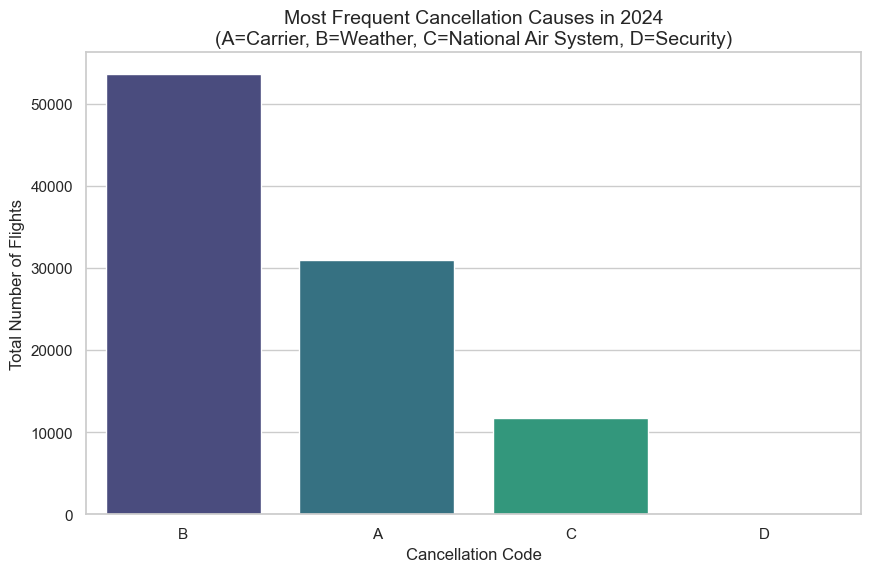

In [11]:
print("Aggregating cancellation causes...")
cancellations = df_full.filter(F.col("cancelled") == "1") \
                       .groupBy("cancellation_code") \
                       .count() \
                       .orderBy("count", ascending=False)

# Creation of Pandas DataFrame for plotting
data_cancellations = cancellations.collect()
df_canc_pd = pd.DataFrame([row.asDict() for row in data_cancellations])
# remove rows where cancellation_code is null (if any)
df_canc_pd = df_canc_pd.dropna(subset=['cancellation_code']) 

print("Drawing the plot...")

# Bar plot of cancellation causes
plt.figure(figsize=(10, 6))
sns.barplot(data=df_canc_pd, x='cancellation_code', y='count', palette='viridis', hue='cancellation_code', legend=False)
plt.title("Most Frequent Cancellation Causes in 2024\n(A=Carrier, B=Weather, C=National Air System, D=Security)", fontsize=14)
plt.xlabel("Cancellation Code", fontsize=12)
plt.ylabel("Total Number of Flights", fontsize=12)
plt.show()

*Observations*:
* Cause B (Weather), responsible for over 50,000 cancellations, is by far the leading cause.
* Code A (**Carrier**) is the second cause (about 30,000 flights), this is a **critical business fact** as it indicates that a huge portion of cancellations is attributable to internal operational problems within the companies.
* **Safety-related issues** (D) are **statistically insignificant** in terms of total volume compared to other causes.

### Distribution of Delays

Calculating delay brackets...


Drawing the pie chart...


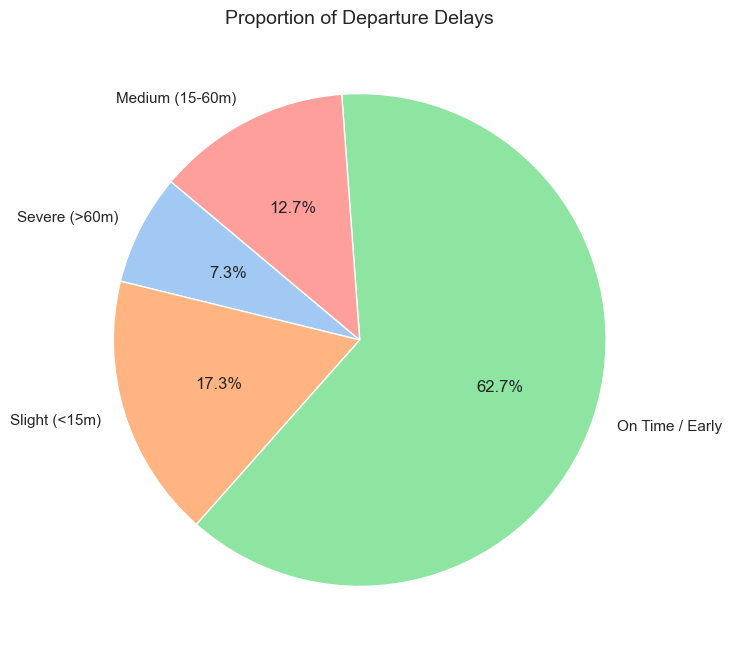

In [12]:
print("Calculating delay brackets...")

# groups the delays in a histogram (excluding on-time/early flights and no-shows)
df_delays = df_full.filter(F.col("dep_delay").isNotNull()) \
                   .withColumn("dep_delay_num", F.col("dep_delay").cast("float"))

# extraction of delay bands
delay_bins = df_delays.withColumn("fascia", 
                    F.when(F.col("dep_delay_num") <= 0, "On Time / Early")
                   .when((F.col("dep_delay_num") > 0) & (F.col("dep_delay_num") <= 15), "Slight (<15m)")
                   .when((F.col("dep_delay_num") > 15) & (F.col("dep_delay_num") <= 60), "Medium (15-60m)")
                   .otherwise("Severe (>60m)")) \
                   .groupBy("fascia").count()

dati_fasce = delay_bins.collect()
df_fasce_pd = pd.DataFrame([row.asDict() for row in dati_fasce])

print("Drawing the pie chart...")

# Pie chart of delay proportions
plt.figure(figsize=(8, 8))
plt.pie(df_fasce_pd['count'], labels=df_fasce_pd['fascia'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Proportion of Departure Delays", fontsize=14)
plt.show()

*Observation*: although almost two thirds of flights (**62.7%**) **depart on time** or even early, it is observed that, adding the "Medium" (12.7%) and "Severe" (7.3%) segments, **1 flight out of 5** (20%) **suffers a delay of more than 15 minutes**, creating potential inconvenience for passengers' connections.

### Outliers Identification
**Descriptive statistics** (mean, median, standard deviation, minimum, maximum, and quartiles) allow to immediately **identify** the presence of **extreme outliers and** to evaluate **skewness** and kurtosis.

In [13]:
print("Casting numeric columns and calculating summary...")

# numeric columns selection and casting to float
numeric_cols = ["arr_delay", "distance", "air_time", "actual_elapsed_time"]
df_num = df_full
for c in numeric_cols:
    df_num = df_num.withColumn(c, F.col(c).cast("float"))

stats_df = df_num.select(numeric_cols).summary("count", "min", "25%", "50%", "75%", "max", "mean")

stats_data = stats_df.collect()
df_stats_pd = pd.DataFrame([row.asDict() for row in stats_data]).set_index('summary')

# rounding to 2 decimal places for better readability
df_stats_pd = df_stats_pd.astype(float).round(2)

print("\nDescriptive Statistics:")
display(df_stats_pd)

Casting numeric columns and calculating summary...



Descriptive Statistics:


,arr_delay,distance,air_time,actual_elapsed_time
summary,,,,
count,6965267.0,7079081.00,6965267.0,6965267.00
min,-126.0,11.00,5.0,15.00
25%,-15.0,399.00,63.0,88.00
50%,-6.0,680.00,98.0,125.00
75%,9.0,1069.00,145.0,172.00
max,3803.0,5095.00,723.0,792.00
mean,7.1,833.91,115.0,141.22


*Observations*:
* The **median** (`50%`) is **-0.6**, meaning more than half of all American flights in 2024 arrived early; however, the **average** (`mean`) is positive (**7.1**). This phenomenon occurs due to **extreme outliers** — also observable by the `max` value of `arr_delay` = 3,803 minutes (at least one plane was delayed more than 63 hours) — extreme cases that **bias the mean upward**, creating a **right-skewed distribution**.
* The `count` value of `distance` = 7,079,081 rows (the exact total of rows in the dataset), while the other columns total is 6,965,267. The difference between these two numbers (approximately 113,814) corresponds exactly to the sum of canceled and diverted flights that never arrived at their destination, further confirming the dataset's consistency.
* As for extreme flights (`distance`), the **longest flight** (`max`) covers **5,095 miles** (probably a continental one); the truly curious anomaly is the **shortest flight** (`min`): **11 miles**, a "hop" between two very close airports (perhaps a flight to reposition the plane or to secondary stopovers on nearby islands).
* By comparing the averages of `act_elapsed_time` (time the plane's doors remain closed with passengers on board), approximately 141 minutes, and `air_time` (time the wheels are off the ground), 115 minutes, it is possible to determine the **average** physiological **time** that American flights waste **taxiing** on the runways before departure and arrival = approximately **26 minutes**.

## Bivariate Analysis
Try to find out **how the variables interact with each other** and, above all, with the target variables (`arr_delay`, `dep_delay`).

### Delays vs. Carrier Performance
This bivariate analysis aims to **highlight that punctuality is not uniformly distributed**: some airlines absorb a disproportionate share of total delays, suggesting that the `carrier` feature is a factor with high predictive power.

Aggregating average delays by carrier...


Drawing the plot...


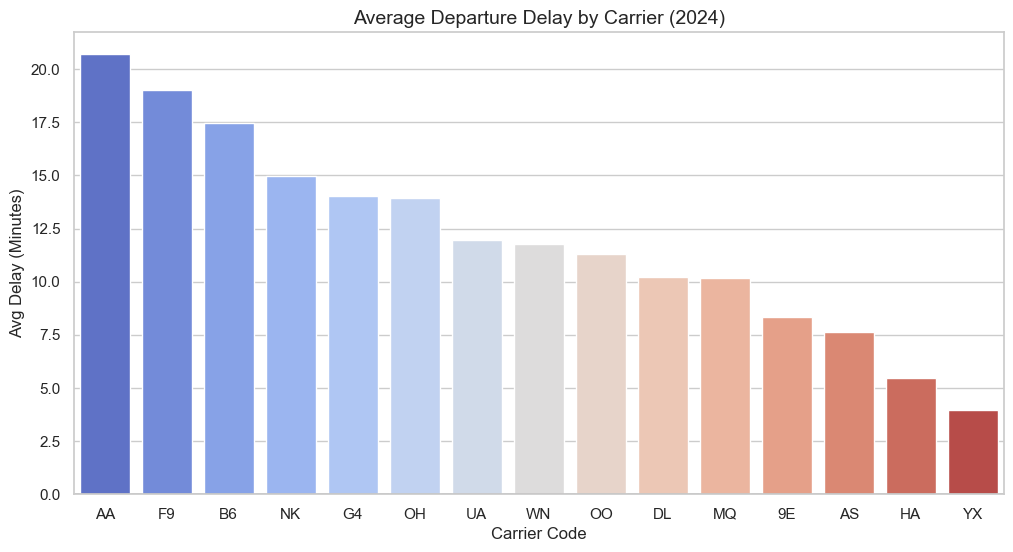

In [14]:
print("Aggregating average delays by carrier...")

# filters out nulls, calculates the average for each company, and sorts in descending order
carrier_delays = df_full.filter(F.col("dep_delay").isNotNull()) \
    .withColumn("dep_delay_num", F.col("dep_delay").cast("float")) \
    .groupBy("op_unique_carrier") \
    .agg(F.mean("dep_delay_num").alias("avg_dep_delay")) \
    .orderBy("avg_dep_delay", ascending=False)

carrier_pd = pd.DataFrame([row.asDict() for row in carrier_delays.collect()])

print("Drawing the plot...")

# Barplot of average departure delay by carrier
plt.figure(figsize=(12, 6))
sns.barplot(data=carrier_pd, x='op_unique_carrier', y='avg_dep_delay', palette='coolwarm', hue='op_unique_carrier', legend=False)
plt.title("Average Departure Delay by Carrier (2024)", fontsize=14)
plt.xlabel("Carrier Code", fontsize=12)
plt.ylabel("Avg Delay (Minutes)", fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.show()

### Trend Analysis of Temporal Effect
The temporal analysis reveals the **impact of seasonality** and **demonstrates the cascade effect** of airport delays.

Aggregating average delays by month...


Drawing the plot...


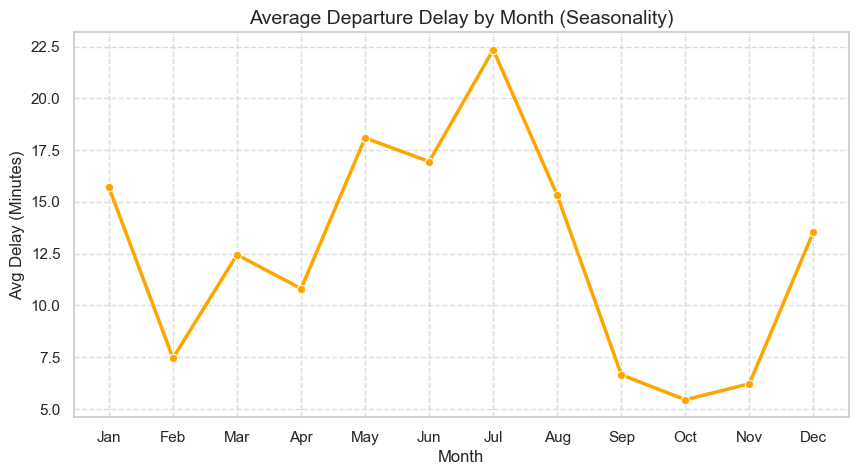

In [15]:
print("Aggregating average delays by month...")

# extract the average for each month
month_delays = df_full.filter(F.col("dep_delay").isNotNull()) \
    .withColumn("dep_delay_num", F.col("dep_delay").cast("float")) \
    .withColumn("month_num", F.col("month").cast("int")) \
    .groupBy("month_num") \
    .agg(F.mean("dep_delay_num").alias("avg_delay")) \
    .orderBy("month_num")

month_pd = pd.DataFrame([row.asDict() for row in month_delays.collect()])

# mapping of month numbers to names
mesi_nomi = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
month_pd['month_name'] = month_pd['month_num'].map(mesi_nomi)

print("Drawing the plot...")

# Lineplot of average departure delay by month
plt.figure(figsize=(10, 5))
sns.lineplot(data=month_pd, x='month_name', y='avg_delay', marker='o', linewidth=2.5, color='orange')
plt.title("Average Departure Delay by Month (Seasonality)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Avg Delay (Minutes)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

*Observations*:
* It is observed that air traffic suffers enormously during the summer (**absolute peak in July**).
* September, October, and November are the best times to travel, with delays dropping dramatically to an average of 5-7 minutes.

Aggregating average delay by hour of the day...


Drawing the line chart...


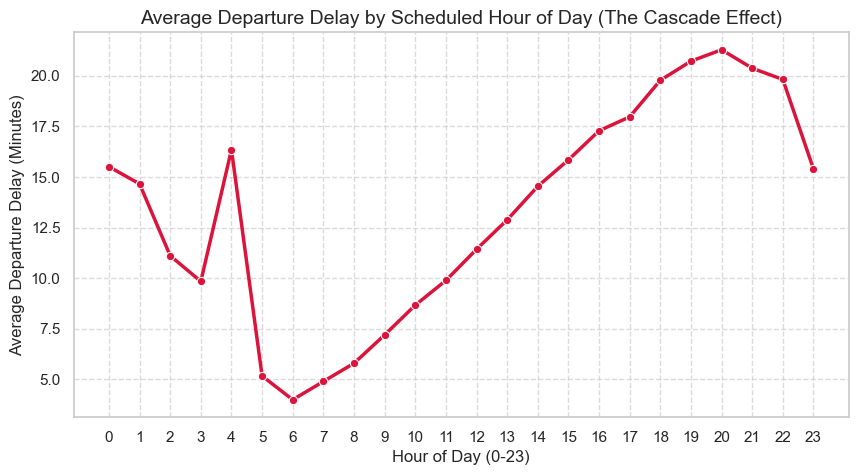

In [17]:
print("Aggregating average delay by hour of the day...")

# extract the hour from crs_dep_time (e.g., 1430 -> 14)
hourly_delays_spark = df_full.filter(F.col("cancelled") == "0") \
    .withColumn("hour", (F.col("crs_dep_time").cast("int") / 100).cast("int")) \
    .filter((F.col("hour") >= 0) & (F.col("hour") <= 23)) \
    .groupBy("hour") \
    .agg(F.mean(F.col("dep_delay").cast("float")).alias("avg_dep_delay")) \
    .orderBy("hour")

hourly_data = hourly_delays_spark.collect()
hourly_delays = pd.DataFrame([row.asDict() for row in hourly_data])

print("Drawing the line chart...")

# Lineplot of average departure delay by hour of the day
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_delays, x='hour', y='avg_dep_delay', marker='o', linewidth=2.5, color='crimson')
plt.title("Average Departure Delay by Scheduled Hour of Day (The Cascade Effect)", fontsize=14)
plt.xlabel("Hour of Day (0-23)", fontsize=12)
plt.ylabel("Average Departure Delay (Minutes)", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

*Observations*:
* The curve hits its **absolute minimum** at **6:00 a.m.**, with an average delay of just 4 minutes. This could be because the planes have spent the night at the gate early in the morning, the crews are fresh, and there are no previous delays to clear. The **system is "reset"**.
* From 6:00 in the morning onwards, the **schedule increases almost linearly for 14 consecutive hours**. This happens because the same plane makes several trips during the day and even trivial delays accumulated in the morning are spread to subsequent flights, the infamous **"cascade effect"**.
* The **maximum peak** is recorded exactly at **8pm** (almost 22 minutes of average delay).
* There's a **sudden and very strange spike at 4:00 a.m.** (over 15 minutes). This is a classic **Big Data "statistical joke"**, a single plane delayed by 3 hours is enough to send the average skyrocketing.

### Recovery Analysis
A scatter plot over a 2% sample to show the **linear correlation between departure and arrival delays**.

*Note*: points below the diagonal represent flights that recovered time during cruise.

Extracting the sample...


Drawing the plot...


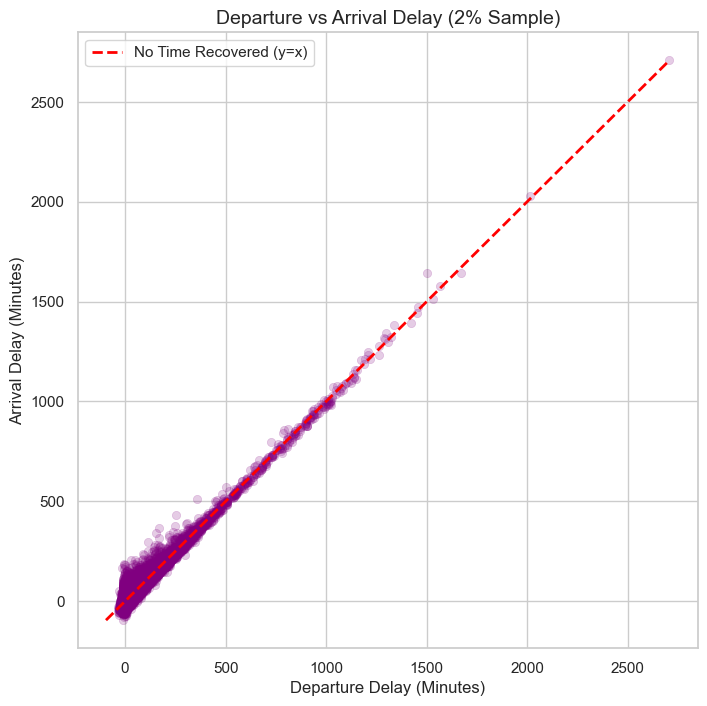

In [18]:
print("Extracting the sample...")

# takes a 2% sample and converts the delay values into float
df_scatter = df_full.filter(F.col("dep_delay").isNotNull() & F.col("arr_delay").isNotNull()) \
    .sample(fraction=0.02, seed=42) \
    .select(F.col("dep_delay").cast("float"), F.col("arr_delay").cast("float"))

scatter_pd = pd.DataFrame([row.asDict() for row in df_scatter.collect()])

print("Drawing the plot...")

# Scatterplot of departure delay vs arrival delay
plt.figure(figsize=(8, 8))
sns.scatterplot(data=scatter_pd, x='dep_delay', y='arr_delay', alpha=0.2, color='purple', edgecolor=None)
# add a reference line where arrival delay equals departure delay (y=x)
min_val = min(scatter_pd['dep_delay'].min(), scatter_pd['arr_delay'].min())
max_val = max(scatter_pd['dep_delay'].max(), scatter_pd['arr_delay'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label="No Time Recovered (y=x)")
# drawing the plot
plt.title("Departure vs Arrival Delay (2% Sample)", fontsize=14)
plt.xlabel("Departure Delay (Minutes)", fontsize=12)
plt.ylabel("Arrival Delay (Minutes)", fontsize=12)
plt.legend()
plt.show()

*Observations*:
* The **strongest linear correlation** is the expected one, that is, that a delay in departure almost always translates into the exact same delay in arrival ($y=x$).
* The most important observation in this case is the **dense cloud of purple points concentrated under the red line**, these represent **flights that departed late but managed to arrive with a delay less** than that accumulated at take-off (making up time in the air).